In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
GREEN_MAIN = "#2e7d32"
%matplotlib inline

In [2]:
df = pd.read_csv("data/synthetic_forecast_cleaned.csv")
print(f"Shape: {df.shape}")
df.head(10)

Shape: (8688, 26)


,timestamp,location_id,meal,year,month,day,hour,minute,day_of_week,week_of_year,is_weekend,hour_frac,hour_sin,hour_cos,month_sin,month_cos,is_holiday,holiday_name,special_event,footfall,footfall_raw,waste_kg,waste_kg_target,waste_organic_kg,waste_recyclable_kg,waste_landfill_kg
0,2025-01-01 00:00:00,b,closed,2025,1,1,0,0,2,1,0,0.0000,0.0000,1.0000,0.5000,0.8660,1,new year's day,nfl playoff watch party,0,0,0.0000,0.0000,0.0000,0.0000,0.0000
1,2025-01-01 00:30:00,d,closed,2025,1,1,0,30,2,1,0,0.5000,0.0000,1.0000,0.5000,0.8660,1,new year's day,nfl playoff watch party,4,4,0.0400,0.0400,0.0200,0.0100,0.0100
2,2025-01-01 01:00:00,d,closed,2025,1,1,1,0,2,1,0,1.0000,0.2588,0.9659,0.5000,0.8660,1,new year's day,nfl playoff watch party,1,1,0.0500,0.0500,0.0200,0.0100,0.0100
3,2025-01-01 01:30:00,b,closed,2025,1,1,1,30,2,1,0,1.5000,0.2588,0.9659,0.5000,0.8660,1,new year's day,nfl playoff watch party,4,4,0.0500,0.0500,0.0200,0.0100,0.0200
4,2025-01-01 02:00:00,d,closed,2025,1,1,2,0,2,1,0,2.0000,0.5000,0.8660,0.5000,0.8660,1,new year's day,nfl playoff watch party,0,0,0.0200,0.0200,0.0100,0.0000,0.0100
5,2025-01-01 02:30:00,d,closed,2025,1,1,2,30,2,1,0,2.5000,0.5000,0.8660,0.5000,0.8660,1,new year's day,nfl playoff watch party,4,4,0.0100,0.0100,0.0000,0.0000,0.0000
6,2025-01-01 03:00:00,c,closed,2025,1,1,3,0,2,1,0,3.0000,0.7071,0.7071,0.5000,0.8660,1,new year's day,nfl playoff watch party,3,3,0.0400,0.0400,0.0200,0.0100,0.0100
7,2025-01-01 03:30:00,d,closed,2025,1,1,3,30,2,1,0,3.5000,0.7071,0.7071,0.5000,0.8660,1,new year's day,nfl playoff watch party,1,1,0.0000,0.0000,0.0000,0.0000,0.0000
8,2025-01-01 04:00:00,d,closed,2025,1,1,4,0,2,1,0,4.0000,0.8660,0.5000,0.5000,0.8660,1,new year's day,nfl playoff watch party,1,1,0.0200,0.0200,0.0100,0.0100,0.0100
9,2025-01-01 04:30:00,d,closed,2025,1,1,4,30,2,1,0,4.5000,0.8660,0.5000,0.5000,0.8660,1,new year's day,nfl playoff watch party,0,0,0.0400,0.0400,0.0200,0.0100,0.0100


In [3]:
# Basic info
df.info()
print("\nMissing values per column:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 8688 entries, 0 to 8687
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp            8688 non-null   str    
 1   location_id          8688 non-null   str    
 2   meal                 8688 non-null   str    
 3   year                 8688 non-null   int64  
 4   month                8688 non-null   int64  
 5   day                  8688 non-null   int64  
 6   hour                 8688 non-null   int64  
 7   minute               8688 non-null   int64  
 8   day_of_week          8688 non-null   int64  
 9   week_of_year         8688 non-null   int64  
 10  is_weekend           8688 non-null   int64  
 11  hour_frac            8688 non-null   float64
 12  hour_sin             8688 non-null   float64
 13  hour_cos             8688 non-null   float64
 14  month_sin            8688 non-null   float64
 15  month_cos            8688 non-null   float64
 16 

In [4]:
# Summary statistics for numerical columns
df.describe()

,year,month,day,hour,minute,day_of_week,week_of_year,is_weekend,hour_frac,hour_sin,hour_cos,month_sin,month_cos,is_holiday,footfall,footfall_raw,waste_kg,waste_kg_target,waste_organic_kg,waste_recyclable_kg,waste_landfill_kg
count,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000,8688.0000
mean,2025.0000,3.5083,15.6022,11.5000,15.0000,3.0110,13.7127,0.2873,11.7500,-0.0000,-0.0000,0.6201,-0.1713,0.0663,37.6865,36.8351,0.8796,0.8796,0.4769,0.2687,0.1330
std,0.0000,1.7101,8.7358,6.9226,15.0009,2.0001,7.4701,0.4525,6.9271,0.7071,0.7071,0.3358,0.6881,0.2488,51.5191,50.6382,1.1520,1.1520,0.6473,0.3680,0.1660
min,2025.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,-1.0000,-1.0000,0.0000,-1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,2025.0000,2.0000,8.0000,5.7500,0.0000,1.0000,7.0000,0.0000,5.8750,-0.7071,-0.7071,0.5000,-0.8660,0.0000,2.0000,2.0000,0.0200,0.0200,0.0100,0.0100,0.0000
50%,2025.0000,4.0000,16.0000,11.5000,15.0000,3.0000,14.0000,0.0000,11.7500,0.0000,-0.0000,0.5000,-0.5000,0.0000,5.0000,5.0000,0.0500,0.0500,0.0200,0.0100,0.0100
75%,2025.0000,5.0000,23.0000,17.2500,30.0000,5.0000,20.0000,1.0000,17.6250,0.7071,0.7071,0.8660,0.5000,0.0000,65.0000,63.0000,1.5300,1.5300,0.8400,0.4400,0.2400
max,2025.0000,6.0000,31.0000,23.0000,30.0000,6.0000,27.0000,1.0000,23.5000,1.0000,1.0000,1.0000,0.8660,1.0000,254.0000,293.0000,6.0000,6.0000,3.3100,1.7300,0.8400


In [5]:
def plot_histogram(data, column, bins=50, kde=True, title=None):
    """Plot a histogram for a numeric column."""
    plt.figure(figsize=(10, 4))
    sns.histplot(data[column], bins=bins, kde=kde, color=GREEN_MAIN)
    plt.title(title or f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Density')
    plt.show()

def plot_count(data, column, title=None, rotation=45):
    """Plot a bar chart of counts for a categorical column."""
    plt.figure(figsize=(8, 5))
    sns.countplot(data=data, x=column, order=data[column].value_counts().index, color=GREEN_MAIN)
    plt.title(title or f'Count of {column}')
    plt.xticks(rotation=rotation)
    plt.show()

def plot_box(data, x, y, title=None):
    """Create a boxplot for a categorical vs numeric."""
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=data, x=x, y=y, color=GREEN_MAIN)
    plt.title(title or f'{y} by {x}')
    plt.xticks(rotation=45)
    plt.show()

def plot_line(data, x, y, title=None):
    """Plot a line chart."""
    plt.figure(figsize=(10, 5))
    sns.lineplot(data=data, x=x, y=y, marker='o', color=GREEN_MAIN)
    plt.title(title or f'{y} vs {x}')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

def barplot_with_percentage(data, x_col, y_col, title, rotate=False, width=0.4):
    """Bar chart with percentage labels on top."""
    df_plot = data.copy()
    total = df_plot[y_col].sum()
    df_plot['Percentage'] = (df_plot[y_col] / total) * 100
    df_plot = df_plot.sort_values(by=y_col, ascending=False).reset_index(drop=True)
    plt.figure(figsize=(10, 6))
    palette = sns.color_palette("Greens", len(df_plot))
    ax = sns.barplot(data=df_plot, x=x_col, y=y_col, hue=x_col, palette=palette, legend=False, width=width)
    max_val = df_plot[y_col].max()
    for i, row in df_plot.iterrows():
        ax.text(i, row[y_col] + (max_val * 0.02), f"{row['Percentage']:.1f}%", ha='center')
    plt.title(title)
    plt.ylim(0, max_val * 1.15)
    if rotate:
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_time_series(data, date_col, value_col, resample_freq='D', title=None):
    """Plot aggregated time series."""
    ts = data.set_index(date_col)[value_col].resample(resample_freq).sum()
    plt.figure(figsize=(14, 5))
    ts.plot(color=GREEN_MAIN)
    plt.title(title or f'{value_col} ({resample_freq} aggregation)')
    plt.ylabel(value_col)
    plt.xlabel('Date')
    plt.grid(True)
    plt.show()
    return ts

# EDA for Canteen Food Waste Forecasting

This notebook performs an exploratory data analysis on the synthetic canteen waste dataset. We examine distributions, temporal patterns, relationships between variables, and identify potential drivers of food waste.

We define a few functions to make plotting simpler and consistent.

## Univariate Analysis

We start by looking at the distribution of the main numerical variables.

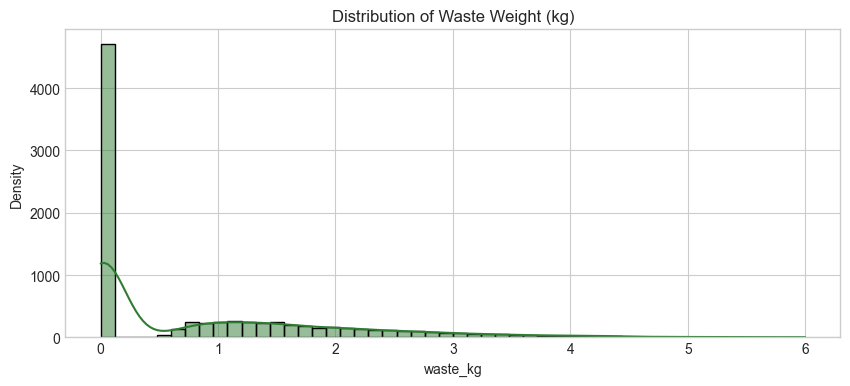

In [6]:
# Distribution of waste_kg
plot_histogram(df, 'waste_kg', bins=50, title='Distribution of Waste Weight (kg)')

The waste weight is heavily right‑skewed: most waste events are small, but there are occasional very large ones. This pattern is common in food waste data and means any prediction model should be able to handle these extremes.

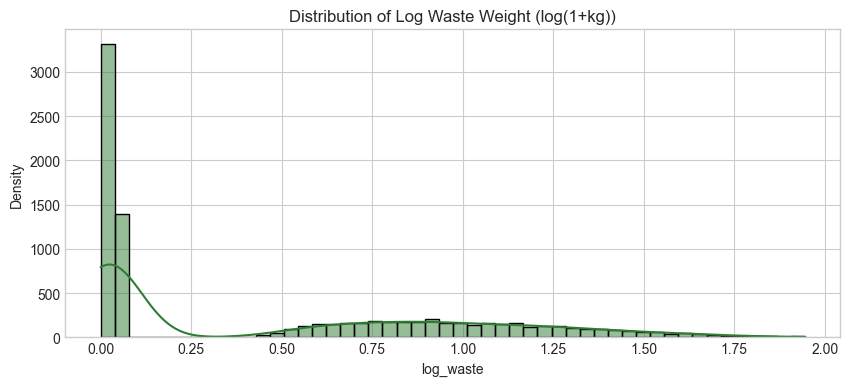

In [7]:
# Log transformation
df['log_waste'] = np.log1p(df['waste_kg'])
plot_histogram(df, 'log_waste', bins=50, title='Distribution of Log Waste Weight (log(1+kg))')

After taking the log, the distribution becomes nearly symmetric, which confirms the waste weights follow a log‑normal pattern. This is useful for modeling.

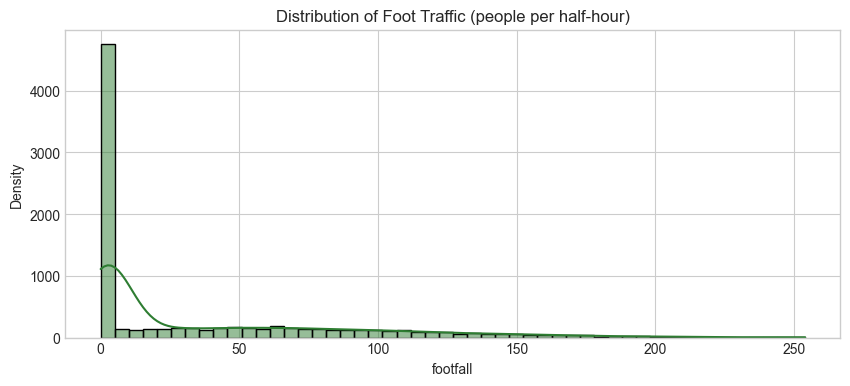

In [8]:
# Distribution of footfall
plot_histogram(df, 'footfall', bins=50, title='Distribution of Foot Traffic (people per half-hour)')

Foot traffic is also right‑skewed, with most half-hour periods having low traffic and a tail of higher values. Peaks occur during meal times.

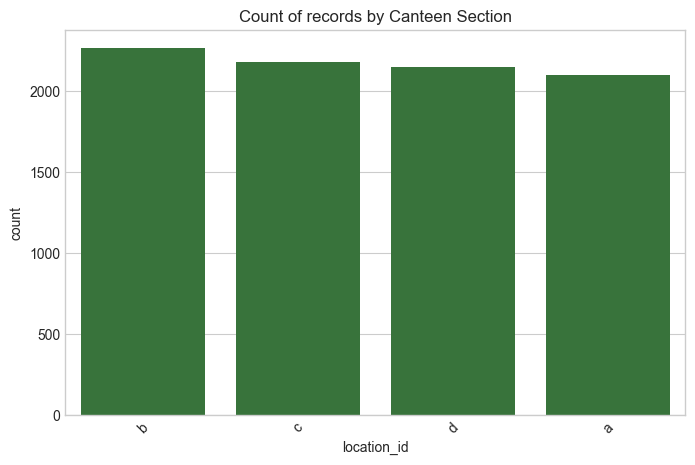

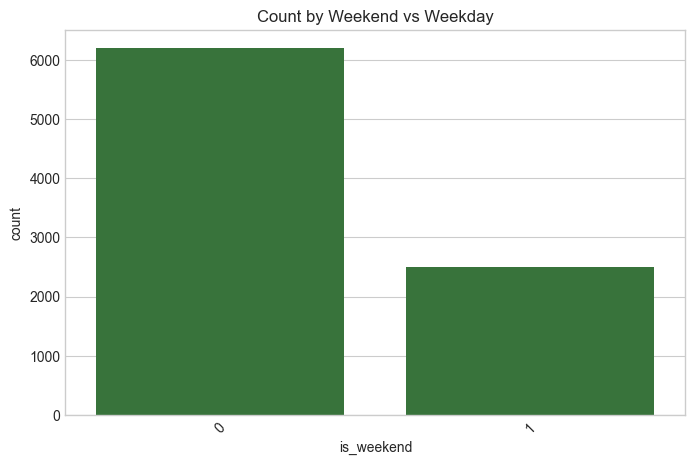

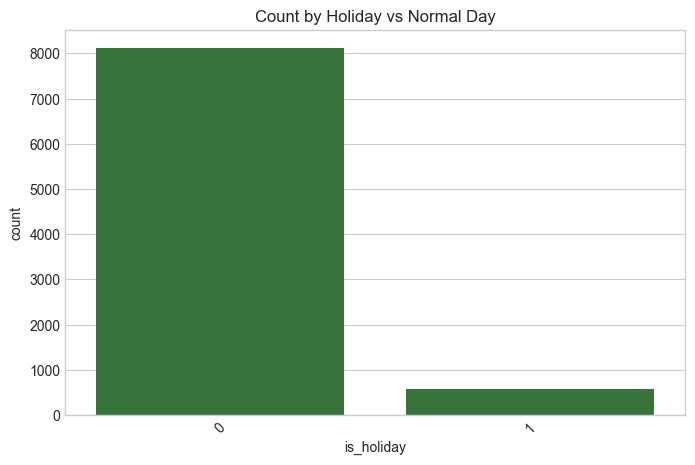

In [9]:
# Count of records by location_id (canteen section)
plot_count(df, 'location_id', title='Count of records by Canteen Section')

# Count by is_weekend
plot_count(df, 'is_weekend', title='Count by Weekend vs Weekday')

# Count by is_holiday
plot_count(df, 'is_holiday', title='Count by Holiday vs Normal Day')

The four canteen sections (A, B, C, D) have very similar numbers of records, which is good for balanced comparisons. Weekend days represent about 2/7 of the data (~28.6%) and holidays are a small fraction (~1-2%).

## Temporal Patterns

Understanding how waste changes over time helps in forecasting and planning.

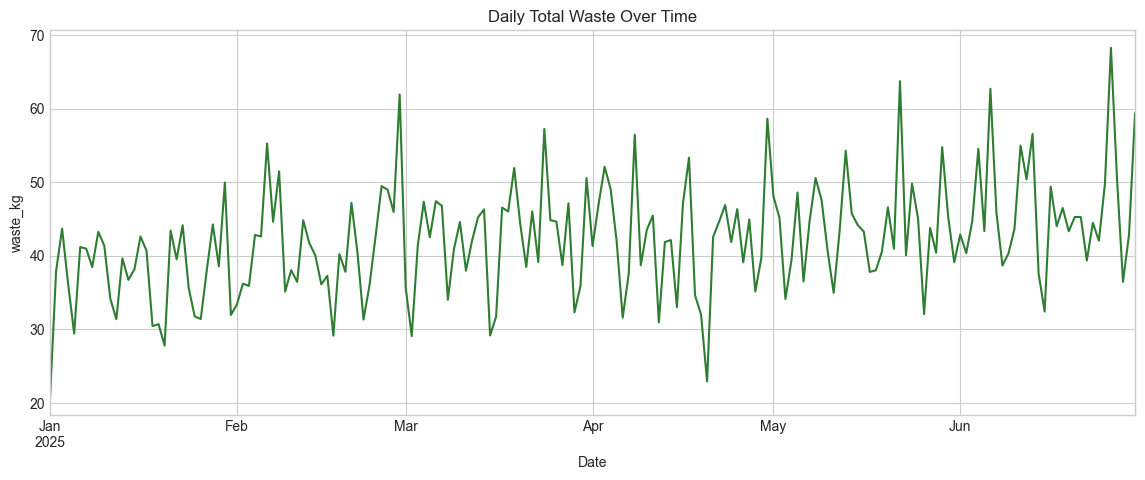

In [10]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Daily total waste over time
daily_waste = plot_time_series(df, 'timestamp', 'waste_kg', resample_freq='D', title='Daily Total Waste Over Time')

Daily waste varies a lot, with clear spikes on some days (likely event days or holidays). There is no strong upward or downward trend over the full period, so the waste level stays fairly stable.

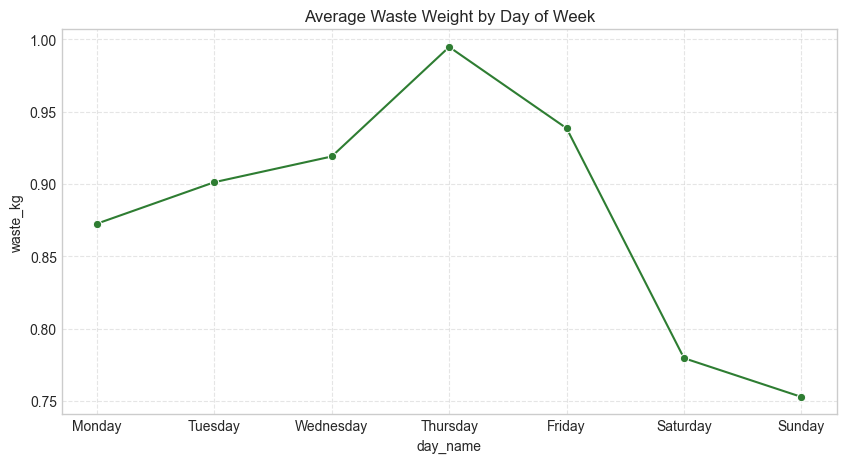

In [11]:
# Average waste by day of week (0=Monday, 6=Sunday)
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_name'] = df['timestamp'].dt.day_name()
avg_waste_dow = df.groupby('day_name')['waste_kg'].mean().reindex(dow_order).reset_index()
plot_line(avg_waste_dow, 'day_name', 'waste_kg', title='Average Waste Weight by Day of Week')

Weekdays (Monday to Friday) have higher waste than weekends (Saturday and Sunday). This matches typical canteen usage: more people on weekdays, so more food waste. Thursday shows the highest waste, while Saturday is the lowest.

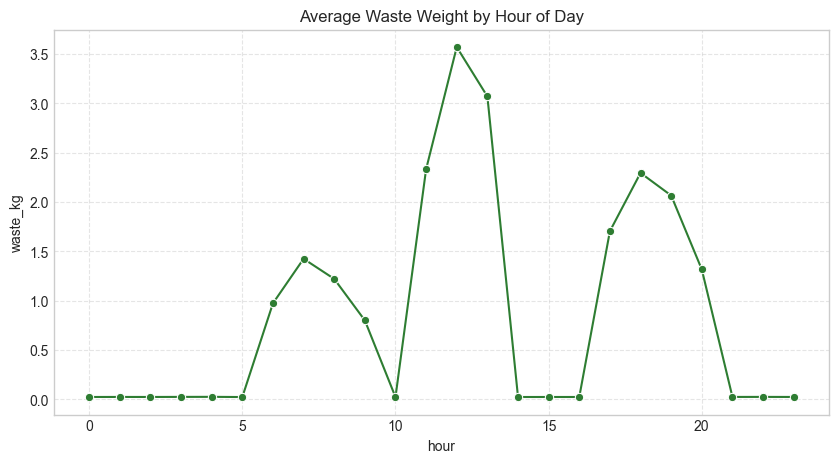

In [12]:
# Average waste by hour
avg_waste_hour = df.groupby('hour')['waste_kg'].mean().reset_index()
plot_line(avg_waste_hour, 'hour', 'waste_kg', title='Average Waste Weight by Hour of Day')

Waste peaks during breakfast (6‑9), lunch (11‑14), and dinner (17‑20) – the times when meals are served. Lunch has the highest peak, followed by dinner. There is almost no waste outside these meal windows.

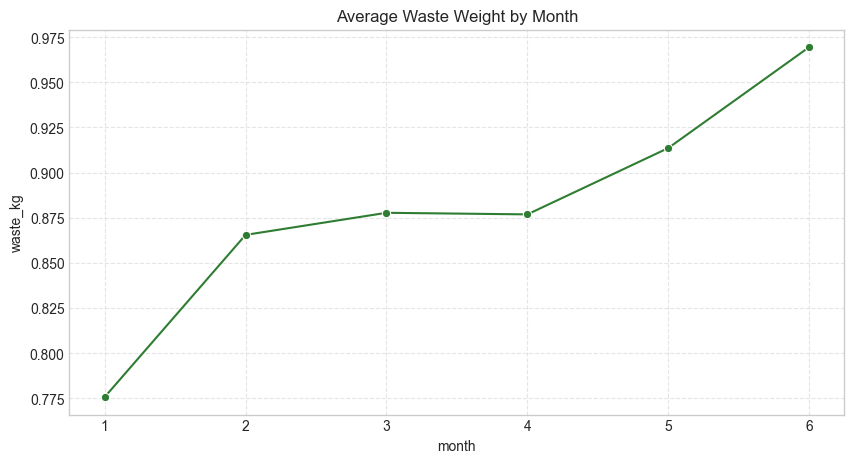

In [13]:
# Average waste by month
avg_waste_month = df.groupby('month')['waste_kg'].mean().reset_index()
plot_line(avg_waste_month, 'month', 'waste_kg', title='Average Waste Weight by Month')

Waste varies by month, with higher amounts in spring (March–May) and lower in summer (June–August). This may be linked to academic schedules (e.g., fewer students in summer). Forecasting models should account for this seasonality.

## Categorical and Multivariate Relationships

We now look at how waste changes across different categories and how numerical variables relate to each other.

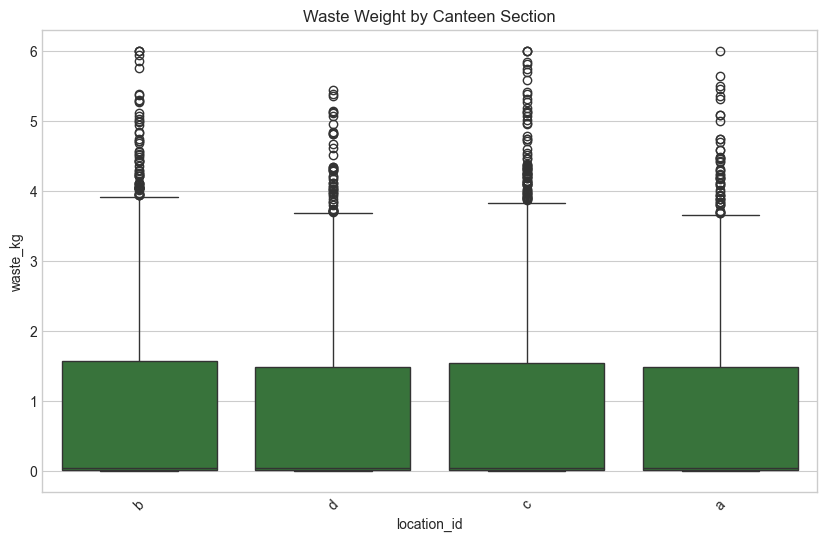

In [14]:
# Waste by canteen section (location_id)
plot_box(df, 'location_id', 'waste_kg', title='Waste Weight by Canteen Section')

Sections D and B have slightly higher median waste, while Section C has the lowest. Section D is the highest priority for waste reduction. Section C could serve as a model for better practices.

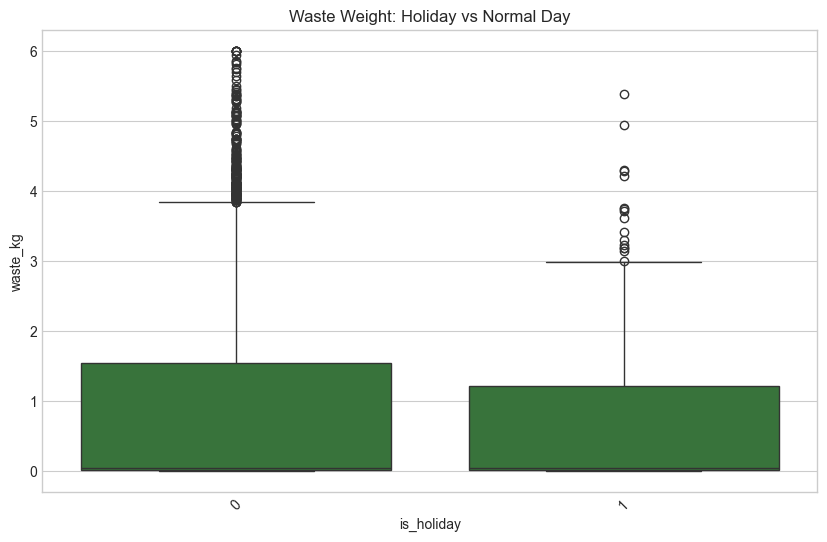

In [15]:
# Waste by holiday status
plot_box(df, 'is_holiday', 'waste_kg', title='Waste Weight: Holiday vs Normal Day')

Holidays show a slightly higher median waste and more extreme outliers, possibly due to special events or different operating hours. However, the difference is not dramatic.

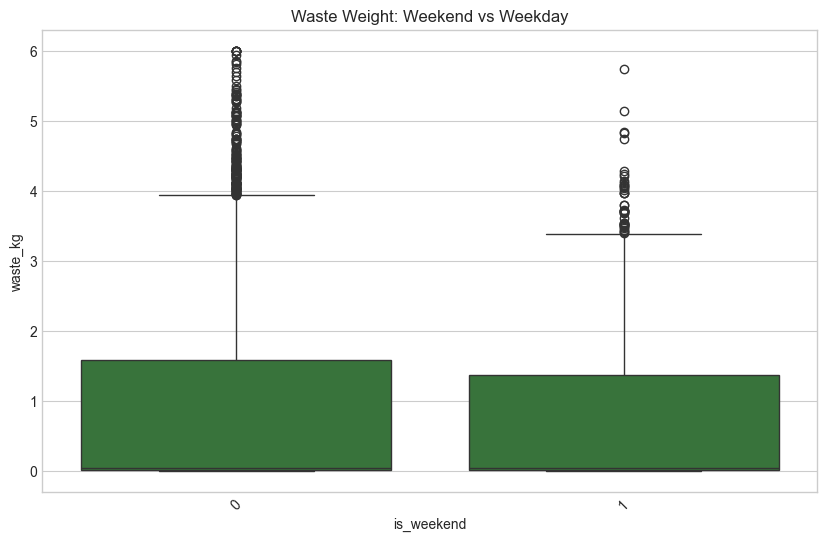

In [16]:
# Waste by weekend status
plot_box(df, 'is_weekend', 'waste_kg', title='Waste Weight: Weekend vs Weekday')

Weekdays have much higher waste than weekends, confirming the day-of-week pattern seen earlier.

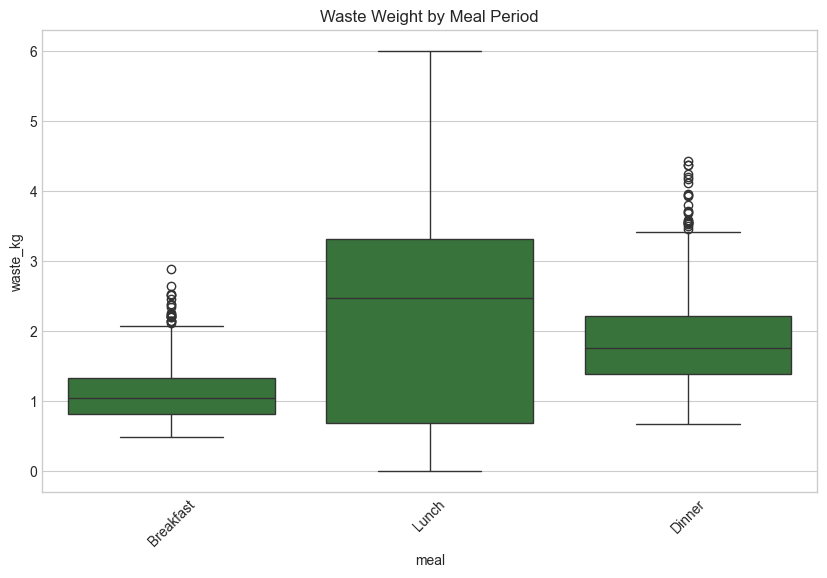

In [17]:
# Derive meal from hour
def get_meal(hour):
    if 6 <= hour < 10:
        return 'Breakfast'
    elif 11 <= hour < 15:
        return 'Lunch'
    elif 17 <= hour < 21:
        return 'Dinner'
    else:
        return 'Other'

df['meal'] = df['hour'].apply(get_meal)
plot_box(df[df['meal'] != 'Other'], 'meal', 'waste_kg', title='Waste Weight by Meal Period')

Lunch has the highest median waste, followed by dinner, then breakfast. This matches typical meal sizes and the multipliers used to generate the synthetic data. The spread is similar across meals, with outliers in each.

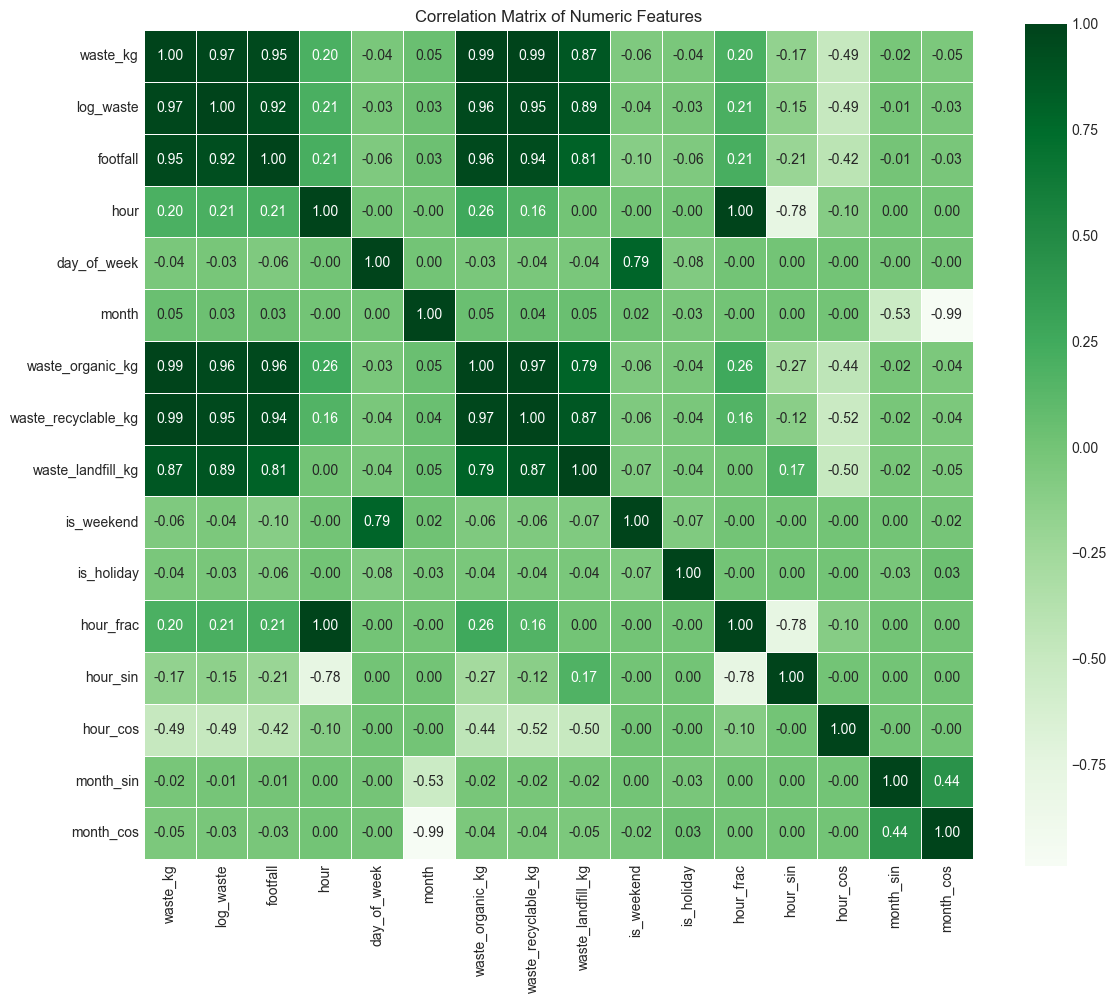

In [18]:
# Select numeric columns for correlation
numeric_cols = ['waste_kg', 'log_waste', 'footfall', 'hour', 'day_of_week', 'month', 
                'waste_organic_kg', 'waste_recyclable_kg', 'waste_landfill_kg',
                'is_weekend', 'is_holiday', 'hour_frac', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Greens', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

Waste_kg has a strong positive link with its components (organic, recyclable, landfill) and with log_waste (as expected). Foot traffic has weak positive links with waste_kg (0.20) and log_waste (0.23), but a moderate negative link with is_weekend (-0.43), which shows that traffic tends to be lower on weekends. Time features like hour_sin/cos and month_sin/cos capture cyclical patterns well. Overall, waste weight and foot traffic are positively related but not extremely strongly – other factors matter too.

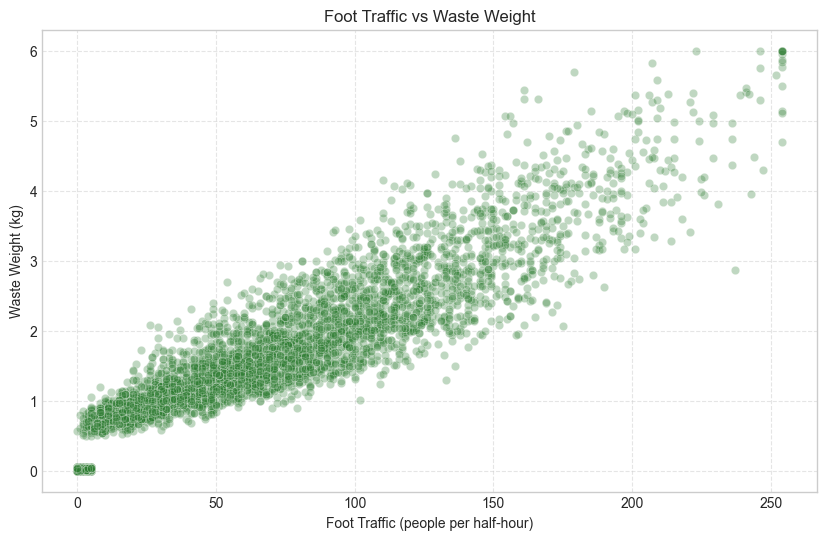

In [19]:
# Scatter plot of foot traffic vs waste weight
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='footfall', y='waste_kg', alpha=0.3, color=GREEN_MAIN)
plt.title('Foot Traffic vs Waste Weight')
plt.xlabel('Foot Traffic (people per half-hour)')
plt.ylabel('Waste Weight (kg)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

The scatter plot shows a clear pattern where waste tends to grow as foot traffic goes up. At low traffic levels, waste values stay small and close together. As traffic gets higher, waste values spread out more and include some much higher points. This means foot traffic likely affects how much waste is produced, but it is not the only factor.

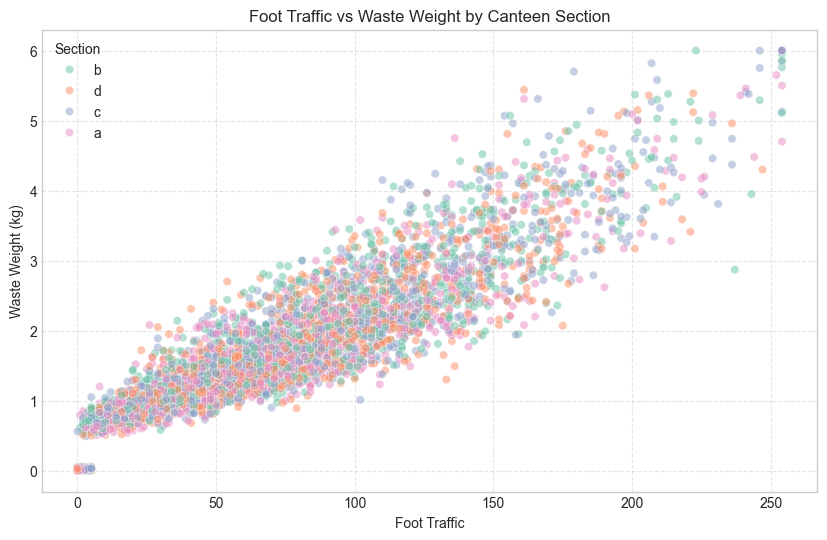

In [20]:
# Scatter with section as hue
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='footfall', y='waste_kg', hue='location_id', alpha=0.5)
plt.title('Foot Traffic vs Waste Weight by Canteen Section')
plt.xlabel('Foot Traffic')
plt.ylabel('Waste Weight (kg)')
plt.legend(title='Section')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Sections with higher base traffic (D and B) show higher waste across the board. Section C, with the lowest traffic, also has the lowest waste. This suggests that controlling traffic (or serving fewer people) directly reduces waste, but we may also need to adjust practices per section.

## Outlier and High‑Waste Analysis

We identify outliers using the IQR rule and high-waste events as those above the 95th percentile.

In [21]:
# Identify outliers
Q1 = df['waste_kg'].quantile(0.25)
Q3 = df['waste_kg'].quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = Q3 + 1.5 * IQR
df['is_outlier'] = df['waste_kg'] > outlier_threshold

# High-waste events (top 5%)
high_threshold = df['waste_kg'].quantile(0.95)
df['is_high_waste'] = df['waste_kg'] > high_threshold

print(f"Outliers: {df['is_outlier'].sum()} records ({df['is_outlier'].mean()*100:.2f}%)")
print(f"High-waste events: {df['is_high_waste'].sum()} records ({df['is_high_waste'].mean()*100:.2f}%)")
print(f"Max waste: {df['waste_kg'].max():.2f} kg")

Outliers: 235 records (2.70%)
High-waste events: 431 records (4.96%)
Max waste: 6.00 kg


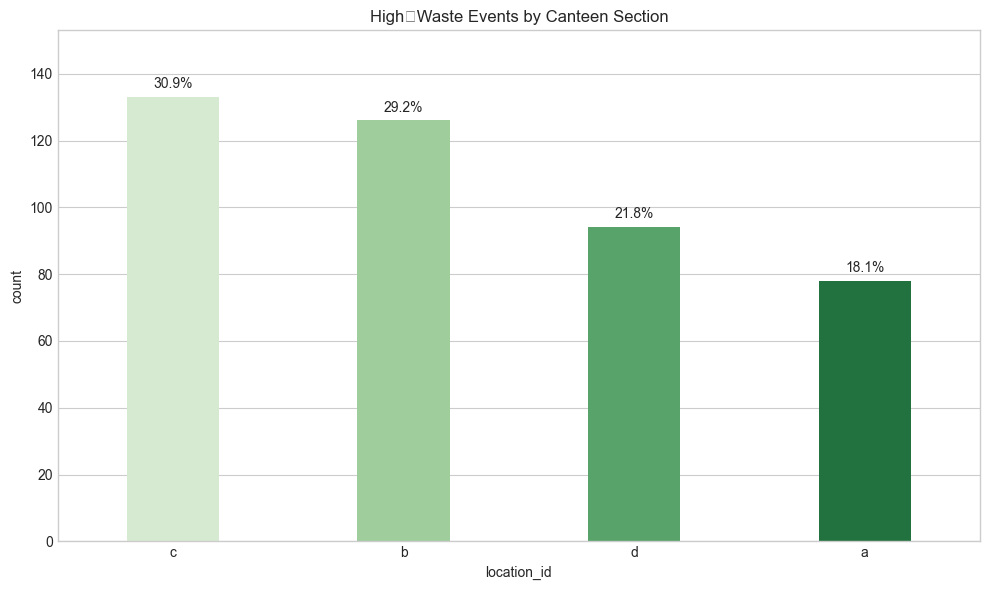

In [22]:
# High-waste events by canteen section
high_waste_by_section = df[df['is_high_waste']].groupby('location_id').size().reset_index(name='count')
barplot_with_percentage(high_waste_by_section, 'location_id', 'count', title='High‑Waste Events by Canteen Section')

Section D has the most high‑waste events, followed by B and A. Section C has the fewest. This aligns with the earlier boxplots and suggests focusing reduction efforts on Section D.

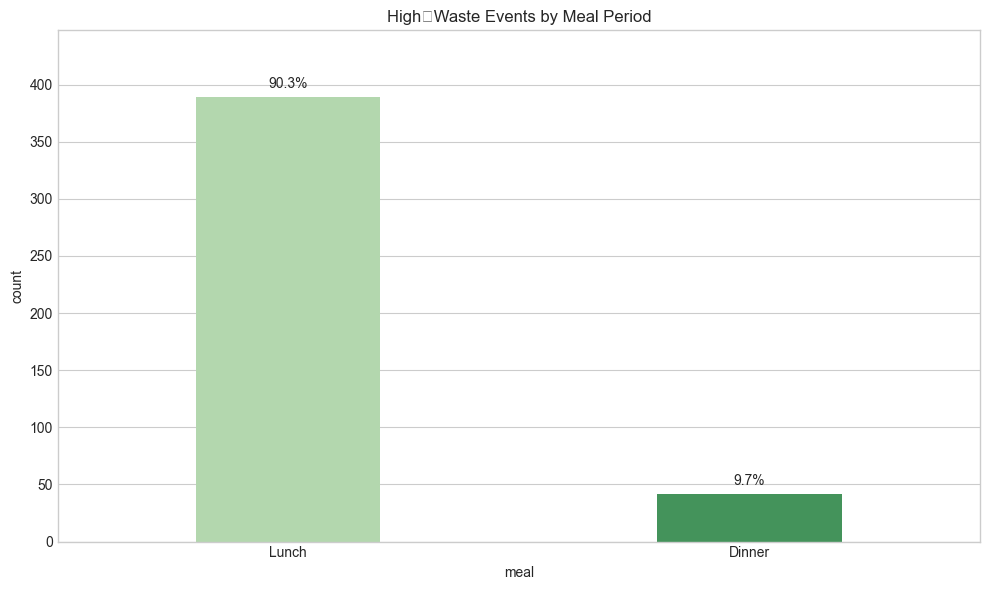

In [23]:
# High-waste events by meal
high_waste_by_meal = df[df['is_high_waste']].groupby('meal').size().reset_index(name='count')
barplot_with_percentage(high_waste_by_meal, 'meal', 'count', title='High‑Waste Events by Meal Period')

Lunch accounts for the majority of high-waste events, followed by dinner. Breakfast has very few. This matches the meal size pattern.

## Foot Traffic Analysis

We examine foot traffic patterns and their relationship with waste.

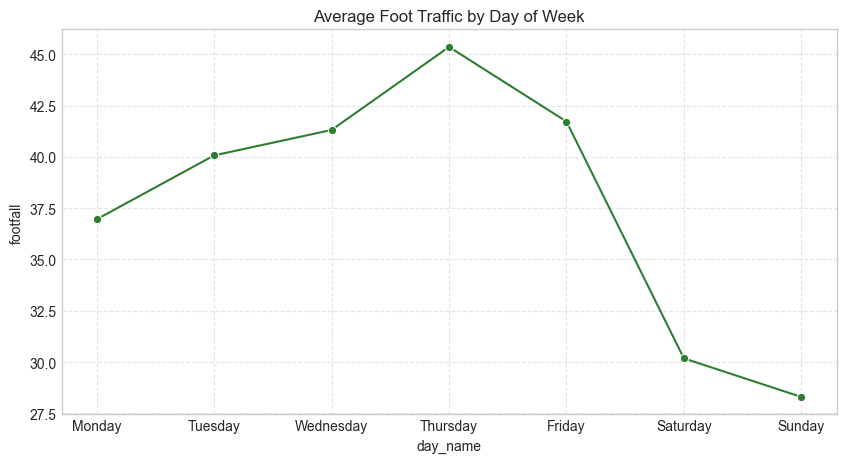

In [24]:
# Average foot traffic by day of week
avg_footfall_dow = df.groupby('day_name')['footfall'].mean().reindex(dow_order).reset_index()
plot_line(avg_footfall_dow, 'day_name', 'footfall', title='Average Foot Traffic by Day of Week')

Weekdays have higher foot traffic than weekends, with Thursday being the busiest and Saturday the quietest. This matches the waste pattern by day of week, confirming that more people lead to more waste.

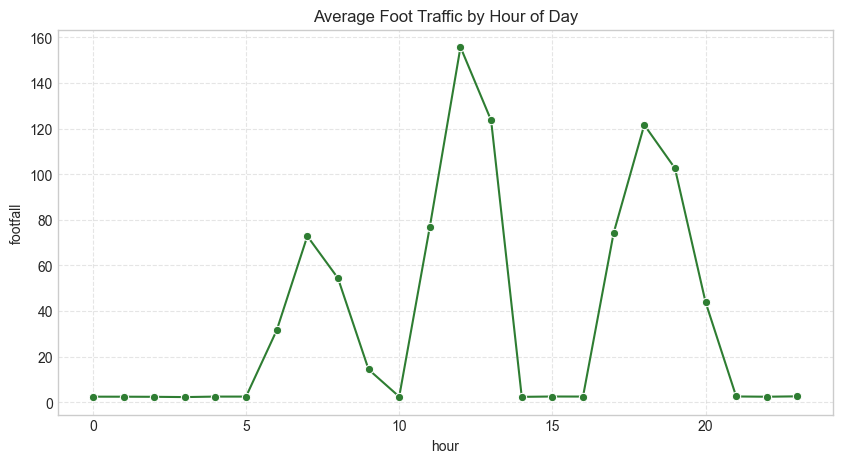

In [25]:
# Average foot traffic by hour
avg_footfall_hour = df.groupby('hour')['footfall'].mean().reset_index()
plot_line(avg_footfall_hour, 'hour', 'footfall', title='Average Foot Traffic by Hour of Day')

Foot traffic peaks during meal hours: breakfast (6‑9), lunch (11‑14), and dinner (17‑20). Lunch sees the highest traffic, followed by dinner. Outside those times, traffic drops to very low levels. This pattern closely matches the waste pattern.

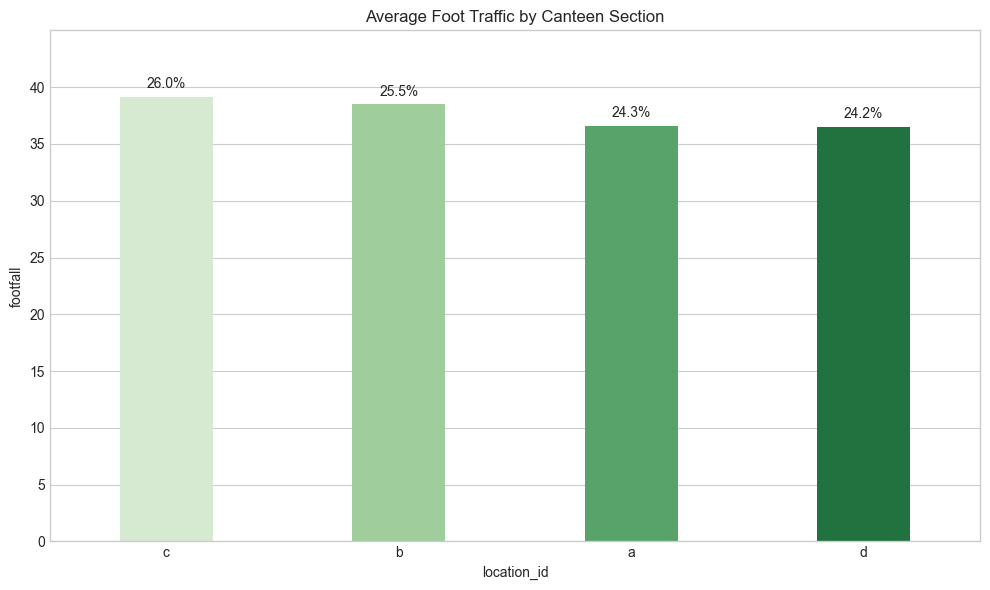

In [26]:
# Average foot traffic by canteen section
avg_footfall_loc = df.groupby('location_id')['footfall'].mean().reset_index()
barplot_with_percentage(avg_footfall_loc, 'location_id', 'footfall', title='Average Foot Traffic by Canteen Section', rotate=False)

Section D has the highest traffic, which means it is the most popular area. Section B comes next. Section A has moderate traffic, and Section C has the lowest traffic. People prefer some sections much more than others.

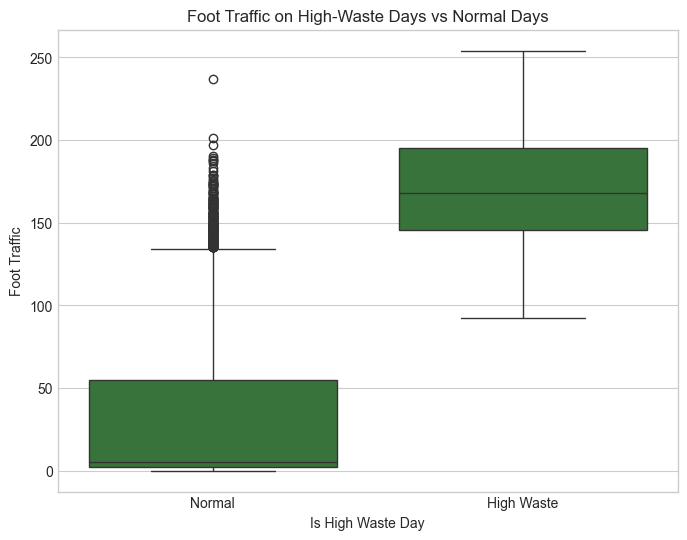

In [27]:
# Foot traffic on high-waste days vs normal days (using is_high_waste as event proxy)
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='is_high_waste', y='footfall', color=GREEN_MAIN)
plt.title('Foot Traffic on High-Waste Days vs Normal Days')
plt.xlabel('Is High Waste Day')
plt.ylabel('Foot Traffic')
plt.xticks([0,1], ['Normal', 'High Waste'])
plt.show()

Days with high waste usually have higher foot traffic than days without high waste. The median is higher for high-waste days, and most of the data also sits at higher traffic levels. At the same time, both groups still have a wide range, which means some low-traffic days can still have high waste and some high-traffic days may not. Overall, higher foot traffic seems linked to high waste events, but it does not fully explain them.

## Time Series Decomposition

We decompose the daily waste series to see trend, weekly seasonality, and residuals.

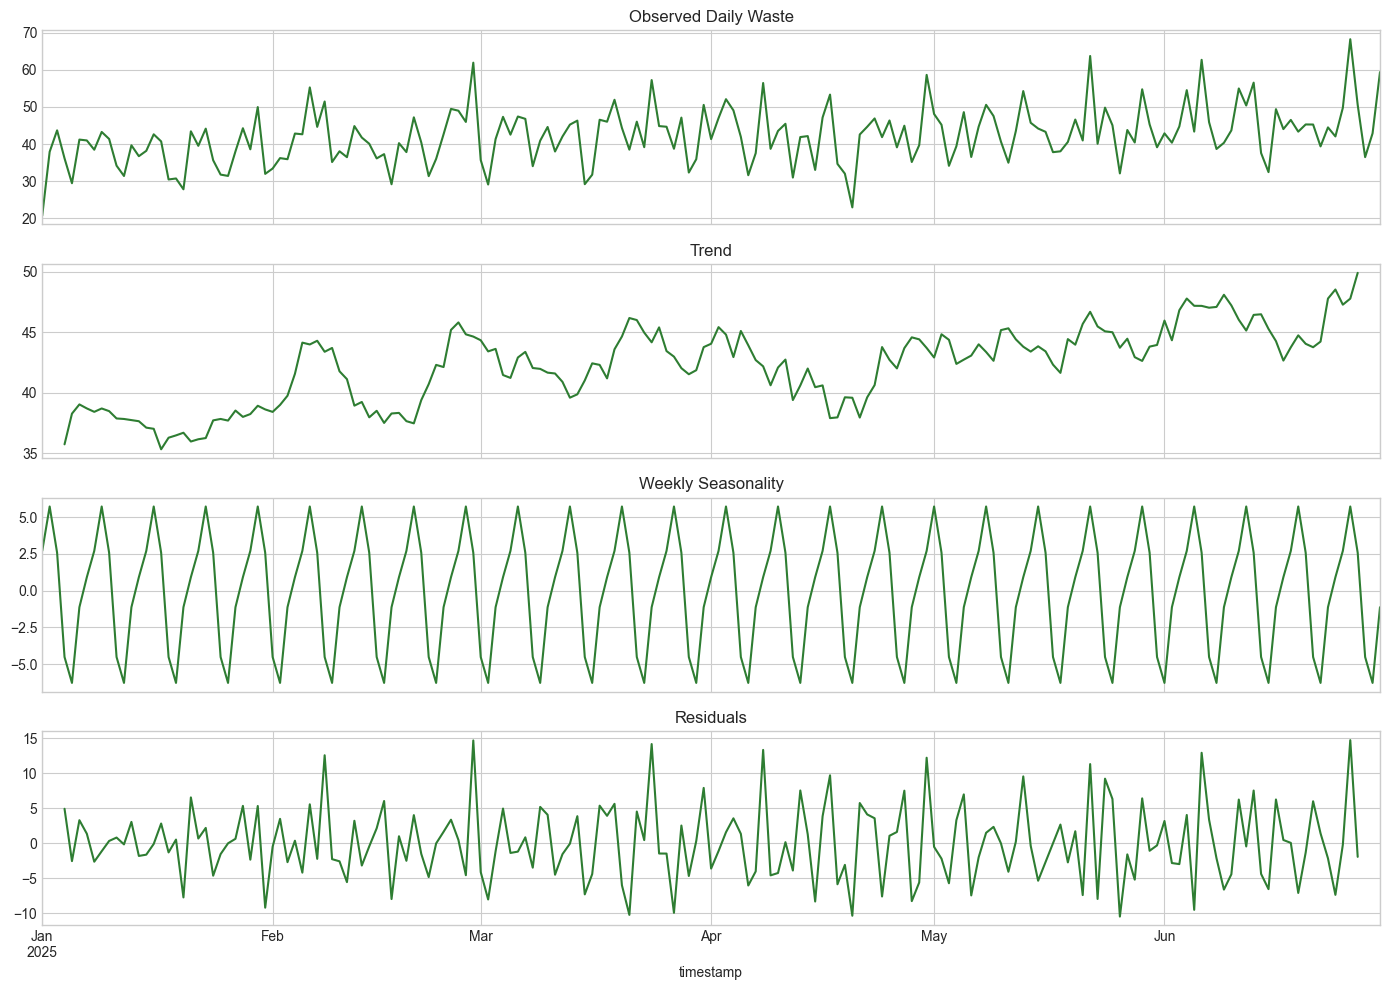

In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Create daily series
daily = df.set_index('timestamp')['waste_kg'].resample('D').sum()
# Fill missing days (if any) with 0
daily = daily.fillna(0)

# Decompose (weekly seasonality)
decomp = seasonal_decompose(daily, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomp.observed.plot(ax=axes[0], color=GREEN_MAIN)
axes[0].set_title('Observed Daily Waste')
decomp.trend.plot(ax=axes[1], color=GREEN_MAIN)
axes[1].set_title('Trend')
decomp.seasonal.plot(ax=axes[2], color=GREEN_MAIN)
axes[2].set_title('Weekly Seasonality')
decomp.resid.plot(ax=axes[3], color=GREEN_MAIN)
axes[3].set_title('Residuals')
plt.tight_layout()
plt.show()

The trend is mostly flat, with only a slight upward drift. The seasonal component shows a clear weekly pattern – higher during weekdays, lower on weekends. The residuals look random, except for some large spikes (likely event days). A model like SARIMA or Prophet that includes weekly seasonality and can handle outliers would work well.

## Key Findings

1. **Waste distribution** is log-normal – suitable for log transformation in modeling.
2. **Temporal patterns**: Waste is highest on weekdays (especially Thursday), during lunch hours, and in spring months.
3. **Canteen sections**: Section D has highest waste and foot traffic; Section C has lowest – a potential benchmark.
4. **Foot traffic** is a moderate predictor of waste, but not sufficient alone.
5. **Outliers** are few but extreme – often associated with high traffic and specific sections (D, B).
6. **Seasonality** is weekly and stable – model should include day-of-week effects.
7. **Event days** (holidays, special events) cause spikes – adding event flags would improve forecasting.